# Multimodal Emotion Recognition using RAVDESS

Cleaned submission notebook. This notebook contains the final working pipeline: data loading, preprocessing, audio model, text GRU model, multimodal fusion, evaluation table, confusion matrix, and loss plots.


In [ ]:
# If any package is missing, uncomment and run this once:
# !pip install librosa tensorflow scikit-learn pandas matplotlib


In [24]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, Model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports done")

Imports done


In [25]:
DATA_DIR = r"C:\Users\vhcha\Downloads\archive (1)\audio_speech_actors_01-24"

wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

print("Number of wav files found:", len(wav_files))
print(wav_files[0] if len(wav_files) else "No files found")

Number of wav files found: 1440
C:\Users\vhcha\Downloads\archive (1)\audio_speech_actors_01-24\Actor_01\03-01-01-01-01-01-01.wav


In [26]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

statement_map = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

def parse_ravdess_filename(path):
    fname = os.path.basename(path)
    parts = fname.replace(".wav", "").split("-")

    emotion_code = parts[2]
    statement_code = parts[4]
    actor_code = parts[6]

    return {
        "path": path,
        "emotion_code": emotion_code,
        "emotion": emotion_map[emotion_code],
        "statement_code": statement_code,
        "transcript": statement_map.get(statement_code, "Unknown transcript"),
        "actor": actor_code
    }

metadata = pd.DataFrame([parse_ravdess_filename(p) for p in wav_files])

print(metadata.shape)
metadata.head()

(1440, 6)


,path,emotion_code,emotion,statement_code,transcript,actor
0,C:\Users\vhcha\Downloads\archive (1)\audio_spe...,01,neutral,01,Kids are talking by the door,01
1,C:\Users\vhcha\Downloads\archive (1)\audio_spe...,01,neutral,01,Kids are talking by the door,01
2,C:\Users\vhcha\Downloads\archive (1)\audio_spe...,01,neutral,02,Dogs are sitting by the door,01
3,C:\Users\vhcha\Downloads\archive (1)\audio_spe...,01,neutral,02,Dogs are sitting by the door,01
4,C:\Users\vhcha\Downloads\archive (1)\audio_spe...,02,calm,01,Kids are talking by the door,01


In [27]:
metadata["emotion"].value_counts()

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

In [28]:
SAMPLE_RATE = 22050
DURATION = 3.0
N_MELS = 128
TARGET_TIME_STEPS = 130

def load_audio_fixed(path, sr=SAMPLE_RATE, duration=DURATION):
    target_len = int(sr * duration)
    y, _ = librosa.load(path, sr=sr)

    y = librosa.util.normalize(y)

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    return y

def audio_to_mel_v2(path):
    y = load_audio_fixed(path)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_mels=N_MELS,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < TARGET_TIME_STEPS:
        pad_width = TARGET_TIME_STEPS - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, pad_width)),
            mode="constant",
            constant_values=mel_db.min()
        )
    else:
        mel_db = mel_db[:, :TARGET_TIME_STEPS]

    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    return mel_db.astype(np.float32)

X_audio = np.array([audio_to_mel_v2(p) for p in metadata["path"]])
X_audio = X_audio[..., np.newaxis]

print("Audio shape:", X_audio.shape)

Audio shape: (1440, 128, 130, 1)


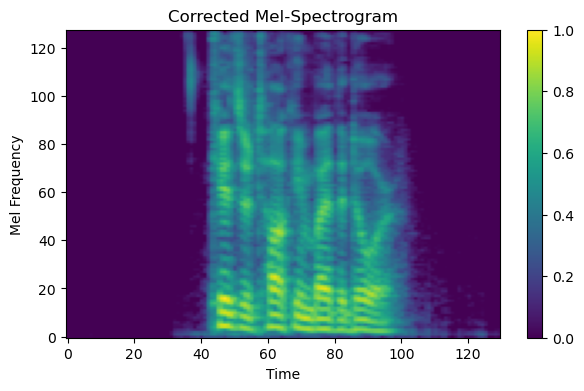

In [29]:
plt.figure(figsize=(7,4))
plt.imshow(X_audio[0].squeeze(), aspect="auto", origin="lower")
plt.title("Corrected Mel-Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar()
plt.show()

In [30]:
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(metadata["emotion"])
num_classes = len(label_encoder.classes_)

y = tf.keras.utils.to_categorical(y_int, num_classes=num_classes)

X_text = metadata["transcript"].astype(str).values

X_audio_train, X_audio_test, X_text_train, X_text_test, y_train, y_test, y_int_train, y_int_test = train_test_split(
    X_audio,
    X_text,
    y,
    y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

print("Classes:", label_encoder.classes_)
print("Train audio:", X_audio_train.shape)
print("Test audio:", X_audio_test.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Train audio: (1152, 128, 130, 1)
Test audio: (288, 128, 130, 1)


In [34]:


def extract_audio_features(path, sr=22050, duration=3.0):
    target_len = int(sr * duration)
    y, _ = librosa.load(path, sr=sr)

    y = librosa.util.normalize(y)

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.std(chroma, axis=1),
        np.mean(mel_db, axis=1),
        np.std(mel_db, axis=1),
    ])

    return features.astype(np.float32)

X_feat = np.array([extract_audio_features(p) for p in metadata["path"]])
print("Feature shape:", X_feat.shape)

Feature shape: (1440, 184)


In [35]:
X_feat_train_full, X_feat_test, X_text_train_full, X_text_test, y_train_full, y_test, y_int_train_full, y_int_test = train_test_split(
    X_feat,
    X_text,
    y,
    y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

X_feat_train, X_feat_val, X_text_train, X_text_val, y_train, y_val, y_int_train, y_int_val = train_test_split(
    X_feat_train_full,
    X_text_train_full,
    y_train_full,
    y_int_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_int_train_full
)

feat_mean = X_feat_train.mean(axis=0)
feat_std = X_feat_train.std(axis=0) + 1e-8

X_feat_train_n = (X_feat_train - feat_mean) / feat_std
X_feat_val_n = (X_feat_val - feat_mean) / feat_std
X_feat_test_n = (X_feat_test - feat_mean) / feat_std

print(X_feat_train_n.shape, X_feat_val_n.shape, X_feat_test_n.shape)

(921, 184) (231, 184) (288, 184)


In [36]:
def build_audio_feature_model(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,), name="audio_feature_input")

    x = layers.Dense(256, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    bottleneck = layers.Dense(64, activation="relu", name="audio_bottleneck")(x)

    out = layers.Dense(num_classes, activation="softmax", name="audio_output")(bottleneck)

    return Model(inp, out, name="Audio_Feature_DNN")

audio_model = build_audio_feature_model(X_feat_train_n.shape[1], num_classes)

audio_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

audio_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True
    )
]

audio_history = audio_model.fit(
    X_feat_train_n,
    y_train,
    validation_data=(X_feat_val_n, y_val),
    epochs=60,
    batch_size=32,
    shuffle=True,
    callbacks=audio_callbacks
)

audio_probs_val = audio_model.predict(X_feat_val_n)
audio_preds_val = np.argmax(audio_probs_val, axis=1)

print("Audio validation accuracy:", accuracy_score(y_int_val, audio_preds_val))
print("Audio validation F1:", f1_score(y_int_val, audio_preds_val, average="weighted", zero_division=0))

Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1716 - loss: 2.3880 - val_accuracy: 0.2554 - val_loss: 1.9391
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3344 - loss: 1.8005 - val_accuracy: 0.3723 - val_loss: 1.7679
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4093 - loss: 1.6188 - val_accuracy: 0.4026 - val_loss: 1.6468
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4625 - loss: 1.5061 - val_accuracy: 0.4935 - val_loss: 1.5351
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5342 - loss: 1.3239 - val_accuracy: 0.4892 - val_loss: 1.4520
Epoch 6/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5527 - loss: 1.2313 - val_accuracy: 0.5281 - val_loss: 1.3860
Epoch 7/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5765 - loss: 1.1679 - val_accuracy: 0.5411 - val_loss: 1.3421
Epoch 8/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6167 - loss: 1.0594 - val_accuracy: 0.5368 - val_loss

In [37]:
MAX_TOKENS = 1000
SEQ_LEN = 20

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN
)

vectorizer.adapt(list(X_text_train))

X_text_train_seq = vectorizer(tf.constant(list(X_text_train))).numpy()
X_text_val_seq = vectorizer(tf.constant(list(X_text_val))).numpy()
X_text_test_seq = vectorizer(tf.constant(list(X_text_test))).numpy()

print("Text train:", X_text_train_seq.shape)
print("Text val:", X_text_val_seq.shape)
print("Text test:", X_text_test_seq.shape)


def build_text_gru(num_classes):
    text_input = layers.Input(shape=(SEQ_LEN,), dtype="int64", name="text_input")

    x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=32, mask_zero=True)(text_input)
    x = layers.GRU(32)(x)

    bottleneck = layers.Dense(32, activation="relu", name="text_bottleneck")(x)
    x = layers.Dropout(0.3)(bottleneck)

    output = layers.Dense(num_classes, activation="softmax", name="text_output")(x)

    return Model(text_input, output, name="Text_GRU")


text_model = build_text_gru(num_classes)

text_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

text_history = text_model.fit(
    X_text_train_seq,
    y_train,
    validation_data=(X_text_val_seq, y_val),
    epochs=20,
    batch_size=32
)

Text train: (921, 20)
Text val: (231, 20)
Text test: (288, 20)
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.1336 - loss: 2.0775 - val_accuracy: 0.1342 - val_loss: 2.0710
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1260 - loss: 2.0704 - val_accuracy: 0.1342 - val_loss: 2.0648
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1336 - loss: 2.0677 - val_accuracy: 0.1342 - val_loss: 2.0615
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1107 - loss: 2.0665 - val_accuracy: 0.1299 - val_loss: 2.0614
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1260 - loss: 2.0640 - val_accuracy: 0.1342 - val_loss: 2.0609
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1216 - loss: 2.0680 - val_accuracy: 0.1342 - val_loss: 2.0611
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1401 - loss: 2.0652 - val_accuracy: 0.1342 - val_loss: 2.0612
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/st

In [38]:

if len(audio_model.input_shape) == 2:
    AUDIO_TRAIN = X_feat_train_n
    AUDIO_VAL = X_feat_val_n
    AUDIO_TEST = X_feat_test_n
    print("Using MFCC/audio-feature input for fusion:", AUDIO_TRAIN.shape)
else:
    AUDIO_TRAIN = X_audio_train_n
    AUDIO_VAL = X_audio_val_n
    AUDIO_TEST = X_audio_test_n
    print("Using Mel-spectrogram CNN input for fusion:", AUDIO_TRAIN.shape)

# Get bottleneck feature layers
audio_features = audio_model.get_layer("audio_bottleneck").output
text_features = text_model.get_layer("text_bottleneck").output

# Concatenate both modalities
combined = layers.Concatenate(name="fusion_concat")([audio_features, text_features])

z = layers.Dense(128, activation="relu")(combined)
z = layers.Dropout(0.4)(z)
z = layers.Dense(64, activation="relu")(z)
z = layers.Dropout(0.3)(z)

fusion_output = layers.Dense(num_classes, activation="softmax", name="fusion_output")(z)

fusion_model = Model(
    inputs=[audio_model.input, text_model.input],
    outputs=fusion_output,
    name="Multimodal_Early_Fusion"
)

fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fusion_model.summary()

fusion_history = fusion_model.fit(
    [AUDIO_TRAIN, X_text_train_seq],
    y_train,
    validation_data=([AUDIO_VAL, X_text_val_seq], y_val),
    epochs=30,
    batch_size=32,
    shuffle=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=8,
            restore_best_weights=True
        )
    ]
)

Using MFCC/audio-feature input for fusion: (921, 184)


Model: "Multimodal_Early_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ audio_feature_input           │ (None, 184)               │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 256)               │          47,360 │ audio_feature_input[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 256)               │           1,024 │ dense_2[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 256)               │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │          32,896 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ text_input (InputLayer)       │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 128)               │             512 │ dense_3[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_4 (Embedding)       │ (None, 20, 32)            │          32,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_4 (NotEqual)        │ (None, 20)                │               0 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 128)               │               0 │ batch_normalization_7[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_4 (GRU)                   │ (None, 32)                │           6,336 │ embedding_4[0][0],         │
│                               │                           │                 │ not_equal_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ audio_bottleneck (Dense)      │ (None, 64)                │           8,256 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ text_bottleneck (Dense)       │ (None, 32)                │           1,056 │ gru_4[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fusion_concat (Concatenate)   │ (None, 96)                │               0 │ audio_bottleneck[0][0],    │
│                               │                           │                 │ text_bottleneck[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 128)               │          12,41

 Total params: 150,632 (588.41 KB)

 Trainable params: 149,864 (585.41 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.1716 - loss: 2.1932 - val_accuracy: 0.3896 - val_loss: 1.7900
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2877 - loss: 1.8484 - val_accuracy: 0.4589 - val_loss: 1.6260
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3811 - loss: 1.6720 - val_accuracy: 0.5195 - val_loss: 1.4901
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4604 - loss: 1.5088 - val_accuracy: 0.5238 - val_loss: 1.3728
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5179 - loss: 1.3444 - val_accuracy: 0.5152 - val_loss: 1.2963
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5537 - loss: 1.2641 - val_accuracy: 0.5714 - val_loss: 1.2488
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5863 - loss: 1.1559 - val_accuracy: 0.5887 - val_loss: 1.2113
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6156 - loss: 1.0996 - val_accuracy: 0.5844 - 

In [39]:
fusion_probs_val = fusion_model.predict([AUDIO_VAL, X_text_val_seq])
fusion_preds_val = np.argmax(fusion_probs_val, axis=1)

print("Fusion validation accuracy:", accuracy_score(y_int_val, fusion_preds_val))
print("Fusion validation F1:", f1_score(y_int_val, fusion_preds_val, average="weighted", zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Fusion validation accuracy: 0.6753246753246753
Fusion validation F1: 0.6708227076416565


In [40]:
def evaluate_model_final(model, X_input, y_true_int, model_name):
    probs = model.predict(X_input)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true_int, preds)
    f1 = f1_score(y_true_int, preds, average="weighted", zero_division=0)

    print("\n" + "="*60)
    print(model_name)
    print("="*60)
    print("Accuracy:", round(acc, 4))
    print("Weighted F1:", round(f1, 4))
    print(classification_report(
        y_true_int,
        preds,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    return acc, f1, preds, probs


audio_acc, audio_f1, audio_preds, audio_probs = evaluate_model_final(
    audio_model,
    AUDIO_TEST,
    y_int_test,
    "Audio-only model"
)

text_acc, text_f1, text_preds, text_probs = evaluate_model_final(
    text_model,
    X_text_test_seq,
    y_int_test,
    "Text-only GRU"
)

fusion_acc, fusion_f1, fusion_preds, fusion_probs = evaluate_model_final(
    fusion_model,
    [AUDIO_TEST, X_text_test_seq],
    y_int_test,
    "Multimodal Early Fusion"
)

results_df = pd.DataFrame({
    "Model": ["Audio-only model", "Text-only GRU", "Multimodal Early Fusion"],
    "Accuracy": [audio_acc, text_acc, fusion_acc],
    "Weighted F1": [audio_f1, text_f1, fusion_f1]
})

results_df

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Audio-only model
Accuracy: 0.5833
Weighted F1: 0.5748
              precision    recall  f1-score   support

       angry       0.62      0.74      0.67        38
        calm       0.66      0.71      0.68        38
     disgust       0.52      0.61      0.56        38
     fearful       0.55      0.79      0.65        39
       happy       0.64      0.46      0.54        39
     neutral       0.38      0.26      0.31        19
         sad       0.48      0.39      0.43        38
   surprised       0.70      0.54      0.61        39

    accuracy                           0.58       288
   macro avg       0.57      0.56      0.56       288
weighted avg       0.58      0.58      0.57       288

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step  

Text-only GRU
Accuracy: 0.125
Weighted F1: 0.0531
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        38
        calm       0.00      0.00      0.00        38
   

,Model,Accuracy,Weighted F1
0,Audio-only model,0.583333,0.574780
1,Text-only GRU,0.125000,0.053105
2,Multimodal Early Fusion,0.576389,0.568773


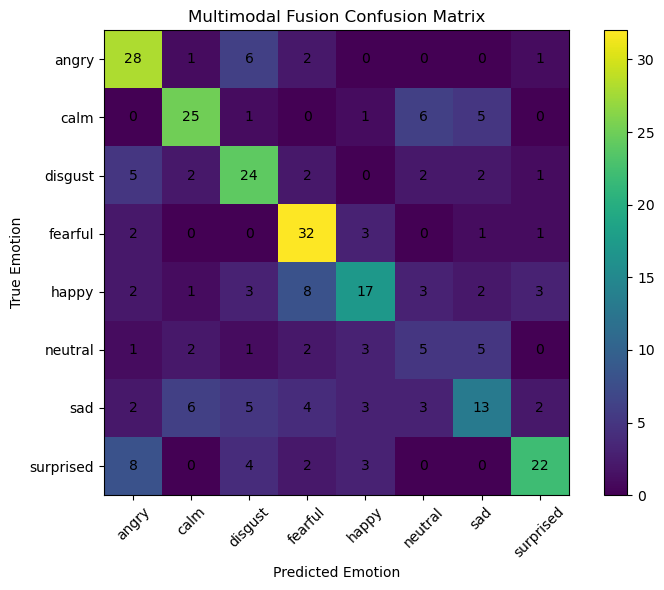

In [41]:
cm = confusion_matrix(y_int_test, fusion_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Multimodal Fusion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(range(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(range(num_classes), label_encoder.classes_)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

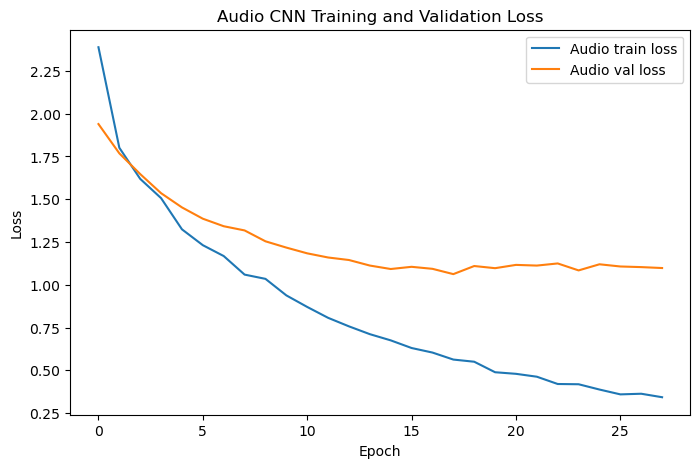

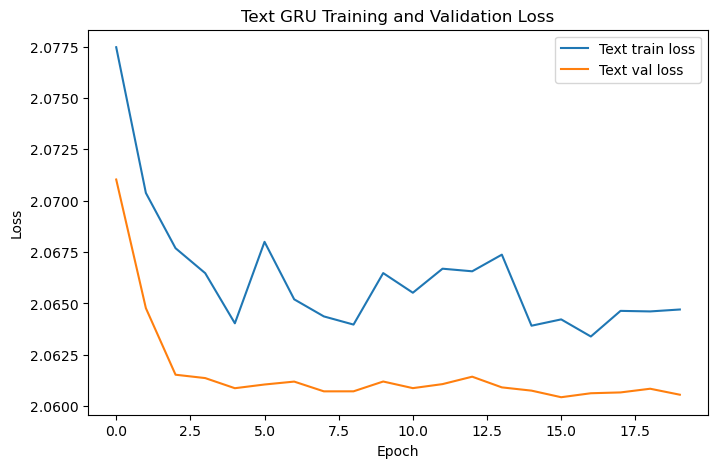

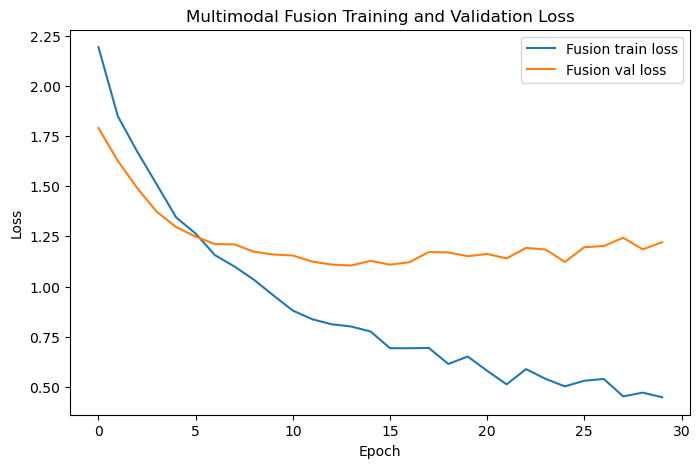

In [42]:
plt.figure(figsize=(8,5))
plt.plot(audio_history.history["loss"], label="Audio train loss")
plt.plot(audio_history.history["val_loss"], label="Audio val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Audio Model Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(text_history.history["loss"], label="Text train loss")
plt.plot(text_history.history["val_loss"], label="Text val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text GRU Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(fusion_history.history["loss"], label="Fusion train loss")
plt.plot(fusion_history.history["val_loss"], label="Fusion val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multimodal Fusion Training and Validation Loss")
plt.legend()
plt.show()

In [43]:
results_df.to_csv("emotion_recognition_results.csv", index=False)
print("Saved results to emotion_recognition_results.csv")

Saved results to emotion_recognition_results.csv
